## Part 1: Intro to PyTorch

#### Importing all the required libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch.nn as nn

!pip install mitdeeplearning --quiet

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
growwapi 1.5.0 requires protobuf<6.0.0,>=5.29.0, but you have protobuf 7.34.1 which is incompatible.
tf-keras 2.20.1 requires tensorflow<2.21,>=2.20, but you have tensorflow 2.21.0 which is incompatible.
streamlit 1.37.1 requires protobuf<6,>=3.20, but you have protobuf 7.34.1 which is incompatible.


#### Creating some basic tensors and evaluating their properties

In [3]:
integer = torch.tensor(1234)
decimal = torch.tensor(3.14159)

print(f"'integer' is a {integer.ndim}-d Tensor: {integer}")
print(f"'decimal' is a {decimal.ndim}-d Tensor: {decimal}")

'integer' is a 0-d Tensor: 1234
'decimal' is a 0-d Tensor: 3.141590118408203


##### We can also use vectors or lists to create tensors

In [5]:
fibonacci = torch.tensor([1, 1, 2, 3, 5, 8])
count_to_100 = torch.tensor(range(100))

print(f"'fibonacci' is a {fibonacci.ndim}-d Tensor with shape: {fibonacci.shape}")
print(f"'count_to_100' is a {count_to_100.ndim}-d Tensor with shape: {count_to_100.shape}")

'fibonacci' is a 1-d Tensor with shape: torch.Size([6])
'count_to_100' is a 1-d Tensor with shape: torch.Size([100])


##### Now we create 2-d matrices and higher order tensors. In Computer Vision and Image Processing, we often use 4-D Tensors with dimensions corresponding to batch_size, number of colour channels, image height and image width

In [6]:
matrix = torch.tensor([[1,2,3], [4,5,6], [7,8,9]])

tensor = torch.zeros((10, 3, 256, 256)) # This represents 10 images with 3 colour channels (particularly RGB) with image size 256 x 256
print(f"'matrix' is a {matrix.ndim}-d Tensor with shape: {matrix.shape}")
print(f"'tensor' is a {tensor.ndim}-d Tensor with shape: {tensor.shape}")

'matrix' is a 2-d Tensor with shape: torch.Size([3, 3])
'tensor' is a 4-d Tensor with shape: torch.Size([10, 3, 256, 256])


##### We can also do slicing so as to access subtensors from a higher order tensor

In [7]:
row_vector = matrix[1]
column_vector = matrix[:,1]
scalar = matrix[1,2]

print(f"'row vector': {row_vector}")
print(f"'column_vector': {column_vector}")
print(f"'scalar': {scalar}")

'row vector': tensor([4, 5, 6])
'column_vector': tensor([2, 5, 8])
'scalar': 6


### Computations on Tensors

##### A convenient way to think about and visualize computations in a machine learning framework like PyTorch is in terms of graphs. We can define this graph in terms of tensors, which hold data, and the mathematical operations that act on these tensors in some order. Let's look at a simple example, and define this computation using PyTorch:

![alt text](https://raw.githubusercontent.com/MITDeepLearning/introtodeeplearning/master/lab1/img/add-graph.png)

In [8]:
# Creating nodes of the graph by initializing tensors
a = torch.tensor(15)
b = torch.tensor(61)

c1 = torch.add(a,b)
c2 = a + b # PyTorch overrides the '+' operation as to act on tensors

print(f"c1: {c1}")
print(f"c2: {c2}")

c1: 76
c2: 76


Now let's consider a slightly more complicated example:

![alt text](https://raw.githubusercontent.com/MITDeepLearning/introtodeeplearning/master/lab1/img/computation-graph.png)

Here, we take two inputs, `a, b`, and compute an output `e`. Each node in the graph represents an operation that takes some input, does some computation, and passes its output to another node.

Let's define a simple function in PyTorch to construct this computation function:

In [10]:
def func(a,b):
    c = torch.add(a,b)
    d = torch.add(b,-1)
    e = torch.mul(c,d)
    return e

a, b = torch.tensor(1.5), torch.tensor(2.5)
e_out = func(a,b)
print(f"Output is {e_out}, type is {type(e_out)}")

Output is 6.0, type is <class 'torch.Tensor'>


## 1.3 Neural networks in PyTorch
We can also define neural networks in PyTorch. PyTorch uses [``torch.nn.Module``](https://pytorch.org/docs/stable/generated/torch.nn.Module.html), which serves as a base class for all neural network modules in PyTorch and thus provides a framework for building and training neural networks.

Let's consider the example of a simple perceptron defined by just one dense (aka fully-connected or linear) layer: $ y = \sigma(Wx + b) $, where $W$ represents a matrix of weights, $b$ is a bias, $x$ is the input, $\sigma$ is the sigmoid activation function, and $y$ is the output.

![alt text](https://raw.githubusercontent.com/MITDeepLearning/introtodeeplearning/master/lab1/img/computation-graph-2.png)

We will use `torch.nn.Module` to define layers -- the building blocks of neural networks. Layers implement common neural networks operations. In PyTorch, when we implement a layer, we subclass `nn.Module` and define the parameters of the layer as attributes of our new class. We also define and override a function [``forward``](https://pytorch.org/docs/stable/generated/torch.nn.Module.html#torch.nn.Module.forward), which will define the forward pass computation that is performed at every step. All classes subclassing `nn.Module` should override the `forward` function.

In [11]:
# Defining a fully connected layer
# num_inputs denotes the number of input nodes
# num_outputs denotes the number of output nodes
# x denotes the input to the layer

class OurDenseNetwork(torch.nn.Module):
    def __init__(self, num_inputs, num_outputs):
        super(OurDenseNetwork, self).__init__()
        # We define and randomly initialize our weight matrix W and a bias vector b
        self.W = torch.nn.Parameter(torch.randn(num_inputs, num_outputs))
        self.b = torch.nn.Parameter(torch.randn(num_outputs))
        
    def forward(self, x):
        z = torch.add(torch.matmul(x, self.W), self.b)
        y = torch.sigmoid(z)
        return y

In [13]:
num_inputs, num_outputs = 2, 3
network = OurDenseNetwork(num_inputs, num_outputs)

x_input = torch.tensor([[1., 2.]]) # The reason we do this, is that PyTorch expects the first dimension to be for batch_size
y = network(x_input)

print(f"input shape is {x_input.shape}")
print(f"output shape is {y.shape}")
print(f"output result: {y}")

input shape is torch.Size([1, 2])
output shape is torch.Size([1, 3])
output result: tensor([[0.8648, 0.0486, 0.2529]], grad_fn=<SigmoidBackward0>)


Now, instead of using a single ```Module``` to define our simple neural network, we'll use the  [`nn.Sequential`](https://pytorch.org/docs/stable/generated/torch.nn.Sequential.html) module from PyTorch and a single [`nn.Linear` ](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html) layer to define our network. With the `Sequential` API, you can readily create neural networks by stacking together layers like building blocks.

In [15]:
num_inputs, num_outputs = 2, 3

network = nn.Sequential(
    nn.Linear(num_inputs, num_outputs),
    nn.Sigmoid()
)

x_input = torch.tensor([[1., 2.]])
output = network(x_input)

print(f"input shape is {x_input.shape}")
print(f"output shape is {output.shape}")
print(f"output result: {output}")

input shape is torch.Size([1, 2])
output shape is torch.Size([1, 3])
output result: tensor([[0.2119, 0.6588, 0.5341]], grad_fn=<SigmoidBackward0>)


As we saw earlier with `OurDenseLayer`, we can subclass `nn.Module` to create a class for our model, and then define the forward pass through the network using the `forward` function. Subclassing affords the flexibility to define custom layers, custom training loops, custom activation functions, and custom models. Let's define the same neural network model as above (i.e., Linear layer with an activation function after it), now using subclassing and using PyTorch's built in linear layer from `nn.Linear`.

In [16]:
class LinearWithSigmoidActivation(nn.Module):
    def __init__(self, num_inputs, num_outputs):
        super(LinearWithSigmoidActivation, self).__init__()
        self.Linear = nn.Linear(num_inputs, num_outputs)
        self.activation = nn.Sigmoid()
        
    def forward(self, input_tensor):
        linear_output = self.Linear(input_tensor)
        output = self.activation(linear_output)
        return output

In [18]:
n_input_nodes, n_output_nodes = 2, 3
network = LinearWithSigmoidActivation(n_input_nodes, n_output_nodes)

x_input = torch.tensor([[1., 2.]])
y = network(x_input)

print(f"input shape: {x_input.shape}")
print(f"output shape: {y.shape}")
print(f"output result: {y}")

input shape: torch.Size([1, 2])
output shape: torch.Size([1, 3])
output result: tensor([[0.4120, 0.3212, 0.3598]], grad_fn=<SigmoidBackward0>)


Importantly, `nn.Module` affords us a lot of flexibility to define custom models. For example, we can use boolean arguments in the `forward` function to specify different network behaviors, for example different behaviors during training and inference. Let's suppose under some instances we want our network to simply output the input, without any perturbation. We define a boolean argument `isidentity` to control this behavior:

In [20]:
class LinearButSometimesIdentity(nn.Module):
    def __init__(self, num_inputs, num_outputs):
        super(LinearButSometimesIdentity, self).__init__()
        self.Linear = nn.Linear(num_inputs, num_outputs)
        
    def forward(self, inputs, isidentity = False):
        if isidentity:
            return inputs
        return self.Linear(inputs)

In [21]:
# Test the IdentityModel
model = LinearButSometimesIdentity(num_inputs=2, num_outputs=3)
x_input = torch.tensor([[1, 2.]])

'''TODO: pass the input into the model and call with and without the input identity option.'''
out_with_linear = model(x_input, False)
out_with_identity = model(x_input, True)

print(f"input: {x_input}")
print("Network linear output: {}; network identity output: {}".format(out_with_linear, out_with_identity))

input: tensor([[1., 2.]])
Network linear output: tensor([[-1.2702, -0.3878,  0.3997]], grad_fn=<AddmmBackward0>); network identity output: tensor([[1., 2.]])


### 1.4 Automatic Differentiation in PyTorch

In PyTorch, [`torch.autograd`](https://pytorch.org/docs/stable/autograd.html) is used for [automatic differentiation](https://en.wikipedia.org/wiki/Automatic_differentiation), which is critical for training deep learning models with [backpropagation](https://en.wikipedia.org/wiki/Backpropagation).

We will use the PyTorch [`.backward()`](https://pytorch.org/docs/stable/generated/torch.Tensor.backward.html) method to trace operations for computing gradients. On a tensor, the [`requires_grad`](https://pytorch.org/docs/stable/generated/torch.Tensor.requires_grad_.html) attribute controls whether autograd should record operations on that tensor. When a forward pass is made through the network, PyTorch builds a computational graph dynamically; then, to compute the gradient, the `backward()` method is called to perform backpropagation.

In [22]:
x = torch.tensor(3.0, requires_grad = True)
y = x**2
y.backward() # This computes the gradient

dy_dx = x.grad
print("dy_dx of y=x^2 at x=3.0 is: ", dy_dx)
assert dy_dx == 6.0

dy_dx of y=x^2 at x=3.0 is:  tensor(6.)


In training neural networks, we use differentiation and stochastic gradient descent (SGD) to optimize a loss function. Now that we have a sense of how PyTorch's autograd can be used to compute and access derivatives, we will look at an example where we use automatic differentiation and SGD to find the minimum of $ L=(x-x_f)^2 $. Here $x_f$ is a variable for a desired value we are trying to optimize for; $L$ represents a loss that we are trying to minimize. While we can clearly solve this problem analytically ($ x_{min}=x_f $), considering how we can compute this using PyTorch's autograd sets us up nicely for future labs where we use gradient descent to optimize entire neural network losses.

Initializing x at 0.3450324535369873


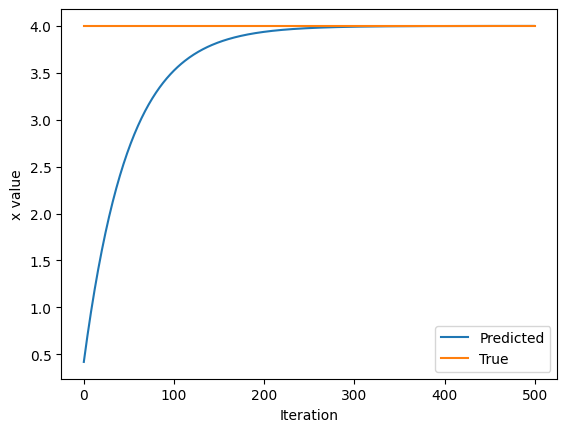

In [27]:
# Initializing a random value for our initial x
x = torch.randn(1)
print(f"Initializing x at {x.item()}")

learning_rate = 1e-2
history = []
x_f = 4

# We run GD for a number of iterations, computing the loss at every iteration
for i in range(500):
    x = torch.tensor([x], requires_grad = True)
    
    loss = (x - x_f)**2
    loss.backward()

    x = x.item() - learning_rate * x.grad
    history.append(x.item())

plt.plot(history)
plt.plot([0, 500], [x_f, x_f])
plt.legend(('Predicted', 'True'))
plt.xlabel('Iteration')
plt.ylabel('x value')
plt.show()